In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
np.random.seed(42)

X shape: (500, 2)
y shape: (500,)


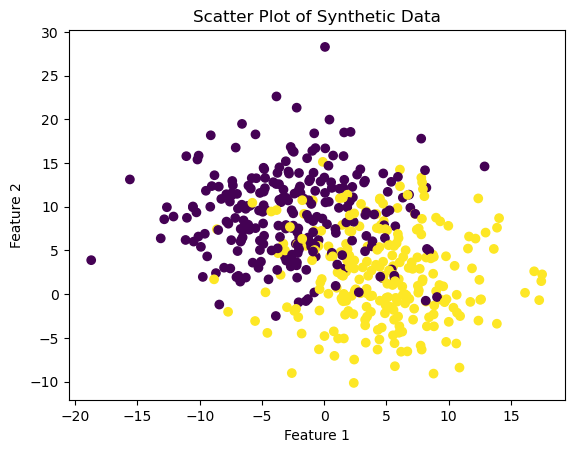

X shape: (500, 2)
y shape: (500,)


In [2]:
X, y = make_blobs(n_samples=500, n_features=2, centers=2, cluster_std=5.0)

print("X shape:", X.shape)
print("y shape:", y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Scatter Plot of Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("X shape:", X.shape)
print("y shape:", y.shape)

In [3]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("Training set shape:", x_train.shape, y_train.shape)
print("Test set shape:", x_test.shape, y_test.shape)

Training set shape: (400, 2) (400,)
Test set shape: (100, 2) (100,)


In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) 

def compute_z(X, w, b):
    z = X @ w + b
    return z

def predict_probability(X, w, b):
    z = compute_z(X, w, b)
    probabilities = sigmoid(z)
    return probabilities

In [5]:
def gradient_descent(X, y, w, b, learning_rate):
    m = X.shape[0]
    probabilities = predict_probability(X, w, b)

    dw = (1/m) * X.T@(probabilities - y)
    db = (1/m) * np.sum(probabilities - y)

    w1 = w - learning_rate*dw
    b1 = b - learning_rate*db
    
    return w1, b1

In [6]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    probabilities = predict_probability(X, w, b)

    epsilon = 1e-15
    probabilities = np.clip(probabilities, epsilon, 1 - epsilon)
    cost = (-1/m) * np.sum(y * np.log(probabilities) + (1-y) * np.log(1-probabilities))

    return cost

In [7]:
def train_logistic_regression(x_train, y_train, learning_rate=0.01, num_iterations=1000):

    w = np.zeros(x_train.shape[1])
    b = 0.0

    cost_history = []
    for i in range(num_iterations):
        w, b = gradient_descent(x_train, y_train, w, b, learning_rate)
        cost = compute_cost(x_train, y_train, w, b)
        cost_history.append(cost)
        if(cost < 0.0000001):
            break

    return w, b, cost_history

In [8]:
learning_rate = 0.01
num_iterations = 200

w, b, cost_history = train_logistic_regression(x_train, y_train, learning_rate, num_iterations)

print("Final weights:", w)
print("Final bias:", b)
print("Final cost:", cost_history[-1])

Final weights: [ 0.30870186 -0.16523015]
Final bias: 0.11218263003568019
Final cost: 0.37987934818917735


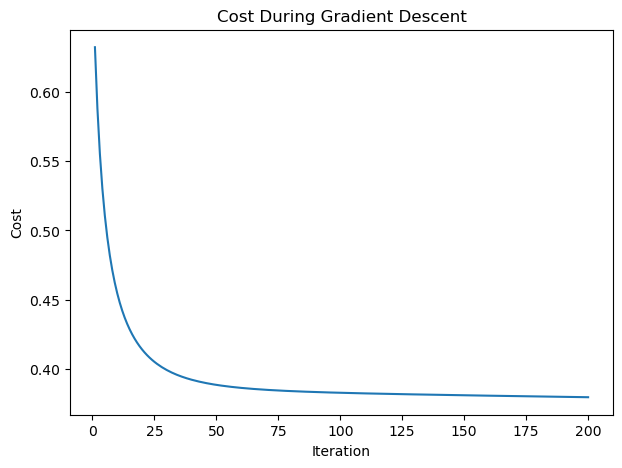

In [9]:
plt.figure(figsize=(7,5))

plt.plot(range(1,len(cost_history)+1),cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")
plt.show()

In [10]:
def predict(X, w, b, threshold):

    n = len(threshold)
    pred = np.zeros((X.shape[0], n))
    accuracy = np.zeros(n)
    for i in range(n):
        pred[:, i] = np.where(predict_probability(X, w, b) >= threshold[i], 1, 0)
        accuracy[i] = np.mean(pred[:, i] == y_test)

    return pred, accuracy

#input threshold values as list
thresholds = [0.3,0.5,0.7]
n = len(thresholds)

y_pred, accuracy = predict(x_test, w, b, thresholds)
output = pd.DataFrame({"Actual": y_test,**{f"Y_pred th={thresholds[i]}": y_pred[:, i].astype(int) for i in range(n)}})
print(output)

for i in range(n):
    print("accuracy for threshold", thresholds[i], ":", accuracy[i])


    Actual  Y_pred th=0.3  Y_pred th=0.5  Y_pred th=0.7
0        0              0              0              0
1        1              1              1              0
2        0              0              0              0
3        1              1              1              0
4        0              0              0              0
..     ...            ...            ...            ...
95       1              0              0              0
96       0              1              1              0
97       1              1              1              0
98       0              0              0              0
99       1              1              1              1

[100 rows x 4 columns]
accuracy for threshold 0.3 : 0.84
accuracy for threshold 0.5 : 0.81
accuracy for threshold 0.7 : 0.71
